In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")  # change if needed

VARIABLE_TOKENS = {
    "sst": "sst",
    "salinity": "so_salinity",
    "u": "u_zonal",
    "v": "v_meridional",
    "thetao": "thetao_potential_temperature",
    "qnet": "net_downward_heat_flux",
}

REGIONS = {
    "UK_coast": dict(lat_min=48, lat_max=62, lon_min=-12, lon_max=4),
    "Subpolar_Gyre": dict(lat_min=50, lat_max=65, lon_min=-45, lon_max=-10),
    "Subtropical_NA": dict(lat_min=25, lat_max=40, lon_min=-60, lon_max=-20),
    "North_Atlantic": dict(lat_min=0, lat_max=90, lon_min=-80, lon_max=2),
}

# ORAS5_YYYY_MM_token_boxed.nc
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

DEPTH_MODE = {
    "sst": None,
    "salinity": "0_100m",
    "u": "0_100m",
    "v": "0_100m",
    "thetao": "0_100m",
    "qnet": None,
}

REGION_NAMES = list(REGIONS.keys())


In [3]:
def time_from_name(path: Path) -> np.datetime64:
    m = FILE_RE.match(path.name)
    if not m:
        raise ValueError(f"Filename didn't match pattern: {path.name}")
    y = int(m.group(1))
    mo = int(m.group(2))
    return np.datetime64(f"{y:04d}-{mo:02d}-01", "ns")

def infer_data_var(ds: xr.Dataset) -> str:
    dvs = list(ds.data_vars)
    if len(dvs) == 1:
        return dvs[0]
    # choose largest variable if multiple
    return max(dvs, key=lambda v: ds[v].size)

def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

def guess_lat_lon_names(obj) -> tuple[str | None, str | None]:
    names = list(obj.coords)
    lat = next((c for c in names if "lat" in c.lower()), None)
    lon = next((c for c in names if "lon" in c.lower()), None)
    return lat, lon

def guess_depth_name(da: xr.DataArray) -> str | None:
    for cand in ["depth", "deptht", "lev", "z"]:
        if cand in da.dims or cand in da.coords:
            return cand
    return None

def guess_spatial_dims(da: xr.DataArray, lat, lon) -> list[str]:
    """
    Works for:
      - curvilinear (nav_lat/nav_lon): dims often ('y','x')
      - regular: dims might be ('lat','lon') or ('latitude','longitude')
    """
    dims = list(da.dims)
    spatial = []
    # if lat/lon are DataArrays with dims, use those dims
    for d in getattr(lat, "dims", ()):
        if d in dims and d not in spatial:
            spatial.append(d)
    for d in getattr(lon, "dims", ()):
        if d in dims and d not in spatial:
            spatial.append(d)
    # fallback common names just in case
    for d in ["y", "x", "lat", "lon", "latitude", "longitude"]:
        if d in dims and d not in spatial:
            spatial.append(d)
    return spatial


In [5]:
def region_mean_from_file(nc_path: Path, region: dict, depth_mode="surface") -> float:
    """
    depth_mode:
      - "surface": take first depth level if present
      - "0_100m": mean over 0-100m if depth coord present
      - None: don't touch depth
    """
    ds = xr.open_dataset(nc_path)

    vname = infer_data_var(ds)
    da = ds[vname]

    # lat/lon coordinates
    lat_name, lon_name = guess_lat_lon_names(da)
    if lat_name is None or lon_name is None:
        lat_name, lon_name = guess_lat_lon_names(ds)
        if lat_name is None or lon_name is None:
            raise ValueError(f"No lat/lon coords found in {nc_path.name}. Coords: {list(ds.coords)}")
        lat = ds[lat_name]
        lon = ds[lon_name]
    else:
        lat = da[lat_name]
        lon = da[lon_name]

    lon = wrap_lon(lon)

    # depth handling
    depth_name = guess_depth_name(da)
    if depth_name is not None and depth_mode is not None:
        if depth_mode == "surface":
            if depth_name in da.dims:
                da = da.isel({depth_name: 0})
        elif depth_mode == "0_100m":
            if depth_name in da.coords:
                da = da.sel({depth_name: slice(0, 100)}).mean(depth_name, skipna=True)
            elif depth_name in da.dims:
                da = da.isel({depth_name: slice(0, 10)}).mean(depth_name, skipna=True)
        else:
            raise ValueError("depth_mode must be 'surface', '0_100m', or None")

    # mask in lat/lon space
    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    spatial_dims = guess_spatial_dims(da, lat, lon)
    if not spatial_dims:
        raise ValueError(f"Could not infer spatial dims for {nc_path.name}; da.dims={da.dims}")

    val = da.where(mask).mean(dim=spatial_dims, skipna=True).values
    arr = np.asarray(val)
    return float(arr.item() if arr.ndim == 0 or arr.size == 1 else np.nanmean(arr))



In [6]:
def build_region_timeseries_for_var(var_name: str, token: str, depth_mode="surface") -> pd.DataFrame:
    files = sorted(DATA_DIR.glob(f"ORAS5_????_??_{token}_boxed.nc"))
    if not files:
        raise FileNotFoundError(f"No files for {var_name} token={token}")

    rows = []
    for f in files:
        t = time_from_name(f)
        row = {"time": t, "variable": var_name}

        for region_name, region in REGIONS.items():
            try:
                row[region_name] = region_mean_from_file(f, region, depth_mode=depth_mode)
            except Exception:
                row[region_name] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("time")


In [7]:
all_series = []

for var_name in ["sst", "salinity", "u", "v", "thetao"]:
    token = VARIABLE_TOKENS[var_name]
    print("Building:", var_name, "| token:", token)
    df_var = build_region_timeseries_for_var(var_name, token, depth_mode=DEPTH_MODE.get(var_name, None))
    all_series.append(df_var)

df_monthly = pd.concat(all_series, ignore_index=True)
df_monthly = df_monthly.sort_values(["variable", "time"]).reset_index(drop=True)

df_monthly.head()


Building: sst | token: sst
Building: salinity | token: so_salinity
Building: u | token: u_zonal
Building: v | token: v_meridional
Building: thetao | token: thetao_potential_temperature


,time,variable,UK_coast,Subpolar_Gyre,Subtropical_NA,North_Atlantic
0,1958-01-01,salinity,35.043407,35.121490,36.578938,35.025150
1,1958-02-01,salinity,35.045811,35.117188,36.536797,35.036991
2,1958-03-01,salinity,35.054405,35.119373,36.512276,35.050446
3,1958-04-01,salinity,35.063248,35.116112,36.503338,35.047028
4,1958-05-01,salinity,35.056129,35.126347,36.531193,35.005962


In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

def _bearing_to_deg(u, v):
    return (np.degrees(np.arctan2(u, v)) + 360.0) % 360.0

def _guess_lat_lon(ds_or_da):
    names = list(ds_or_da.coords)
    lat = next((c for c in names if "lat" in c.lower()), None)
    lon = next((c for c in names if "lon" in c.lower()), None)
    return lat, lon

def _guess_depth(ds_or_da):
    for cand in ["depth", "deptht", "depthu", "depthv", "lev", "z"]:
        if cand in ds_or_da.coords or cand in getattr(ds_or_da, "dims", ()):
            return cand
    return None

def current_rose_from_files(
    data_dir: Path,
    u_token: str,
    v_token: str,
    region: dict,
    depth_mode="0_100m",          # "surface", "0_100m", or None
    n_sectors=16,
    speed_bins=(0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8),
    direction="to",
    max_files=None,
    title=None,
):
    u_files = sorted(data_dir.glob(f"ORAS5_????_??_{u_token}_boxed.nc"))
    v_files = sorted(data_dir.glob(f"ORAS5_????_??_{v_token}_boxed.nc"))

    if not u_files or not v_files:
        raise FileNotFoundError("Couldn't find u/v files for the provided tokens.")

    # match by YYYY_MM in filename
    def ym(p): return (p.name.split("_")[1], p.name.split("_")[2])
    u_map = {ym(p): p for p in u_files}
    v_map = {ym(p): p for p in v_files}
    keys = sorted(set(u_map) & set(v_map))
    if max_files is not None:
        keys = keys[:max_files]

    U_all = []
    V_all = []

    for k in keys:
        pu = u_map[k]
        pv = v_map[k]

        dsu = xr.open_dataset(pu)
        dsv = xr.open_dataset(pv)

        u_name = infer_data_var(dsu)
        v_name = infer_data_var(dsv)

        u = dsu[u_name]
        v = dsv[v_name]

        # lat/lon
        lat_name, lon_name = guess_lat_lon_names(u)
        if lat_name is None or lon_name is None:
            lat_name, lon_name = guess_lat_lon_names(dsu)
            lat = dsu[lat_name]; lon = dsu[lon_name]
        else:
            lat = u[lat_name]; lon = u[lon_name]

        lon = wrap_lon(lon)

        # depth handling
        def apply_depth(da):
            depth_name = guess_depth_name(da)
            if depth_name is not None and depth_mode is not None:
                if depth_mode == "surface":
                    if depth_name in da.dims:
                        da = da.isel({depth_name: 0})
                elif depth_mode == "0_100m":
                    if depth_name in da.coords:
                        da = da.sel({depth_name: slice(0, 100)}).mean(depth_name, skipna=True)
                    elif depth_name in da.dims:
                        da = da.isel({depth_name: slice(0, 10)}).mean(depth_name, skipna=True)
                else:
                    raise ValueError("depth_mode must be 'surface', '0_100m', or None")
            return da

        u = apply_depth(u)
        v = apply_depth(v)

        mask = (
            (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
            (lon >= region["lon_min"]) & (lon <= region["lon_max"])
        )

        spatial_dims_u = guess_spatial_dims(u, lat, lon)
        spatial_dims_v = guess_spatial_dims(v, lat, lon)

        # flatten all in region
        u_vals = np.asarray(u.where(mask)).ravel()
        v_vals = np.asarray(v.where(mask)).ravel()

        m = np.isfinite(u_vals) & np.isfinite(v_vals)
        u_vals = u_vals[m]
        v_vals = v_vals[m]

        if u_vals.size:
            U_all.append(u_vals)
            V_all.append(v_vals)

        dsu.close(); dsv.close()

    if not U_all:
        raise ValueError("No finite u/v samples found after subsetting.")

    U = np.concatenate(U_all)
    V = np.concatenate(V_all)

    speed = np.sqrt(U**2 + V**2)
    bearing_to = _bearing_to_deg(U, V)
    bearing = (bearing_to + 180.0) % 360.0 if direction == "from" else bearing_to

    # binning
    speed_bins = np.asarray(speed_bins)
    sector_edges = np.linspace(0, 360, n_sectors + 1)
    sector_centers = np.deg2rad((sector_edges[:-1] + sector_edges[1:]) / 2)
    sector_width = np.deg2rad(360 / n_sectors)

    counts = np.zeros((n_sectors, len(speed_bins) - 1), dtype=float)
    sec_idx = np.digitize(bearing, sector_edges) - 1
    sec_idx = np.clip(sec_idx, 0, n_sectors - 1)

    sp_idx = np.digitize(speed, speed_bins) - 1
    valid = (sp_idx >= 0) & (sp_idx < len(speed_bins) - 1)

    for s, b in zip(sec_idx[valid], sp_idx[valid]):
        counts[s, b] += 1

    counts = 100.0 * counts / counts.sum()

    # plot
    fig = plt.figure(figsize=(7.5, 7.5))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    bottom = np.zeros(n_sectors)
    for j in range(counts.shape[1]):
        ax.bar(sector_centers, counts[:, j], width=sector_width*0.95, bottom=bottom, align="center", edgecolor="none")
        bottom += counts[:, j]

    labels = [f"{speed_bins[i]:.3g}–{speed_bins[i+1]:.3g}" for i in range(len(speed_bins)-1)]
    ax.legend(labels, title="Speed bins", loc="lower left", bbox_to_anchor=(1.02, 0.0), frameon=False)
    ax.set_title(title or f"Current rose ({u_token}, {v_token}) | {direction}-direction", pad=18)
    plt.tight_layout()
    plt.show()

current_rose_from_files(
    DATA_DIR,
    u_token=VARIABLE_TOKENS["u"],
    v_token=VARIABLE_TOKENS["v"],
    region=REGIONS["UK_coast"],
    depth_mode="0_100m",
    n_sectors=16,
    speed_bins=(0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8),
    direction="to",
    title="UK coast current rose (0–100 m)"
)


Data variables:


NameError: name 'ds' is not defined

In [9]:
from pathlib import Path
import xarray as xr

# pick one u file
example_u = sorted(DATA_DIR.glob(f"ORAS5_????_??_{VARIABLE_TOKENS['u']}_boxed.nc"))[0]

ds_u = xr.open_dataset(example_u)

print("Variables in u file:")
for k in ds_u.data_vars:
    print(" -", k)

print("\nCoordinates:")
print(ds_u.coords)


Variables in u file:
 - vozocrtx

Coordinates:
Coordinates:
  * depthu        (depthu) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
    nav_lat       (y, x) float32 759kB ...
    nav_lon       (y, x) float32 759kB ...
  * time_counter  (time_counter) datetime64[ns] 8B 1958-01-16


In [10]:
example_v = sorted(DATA_DIR.glob(f"ORAS5_????_??_{VARIABLE_TOKENS['v']}_boxed.nc"))[0]
ds_v = xr.open_dataset(example_v)

print("Variables in v file:")
for k in ds_v.data_vars:
    print(" -", k)

print("\nCoordinates:")
print(ds_v.coords)


Variables in v file:
 - vomecrty

Coordinates:
Coordinates:
  * depthv        (depthv) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
    nav_lat       (y, x) float32 761kB ...
    nav_lon       (y, x) float32 761kB ...
  * time_counter  (time_counter) datetime64[ns] 8B 1958-01-16


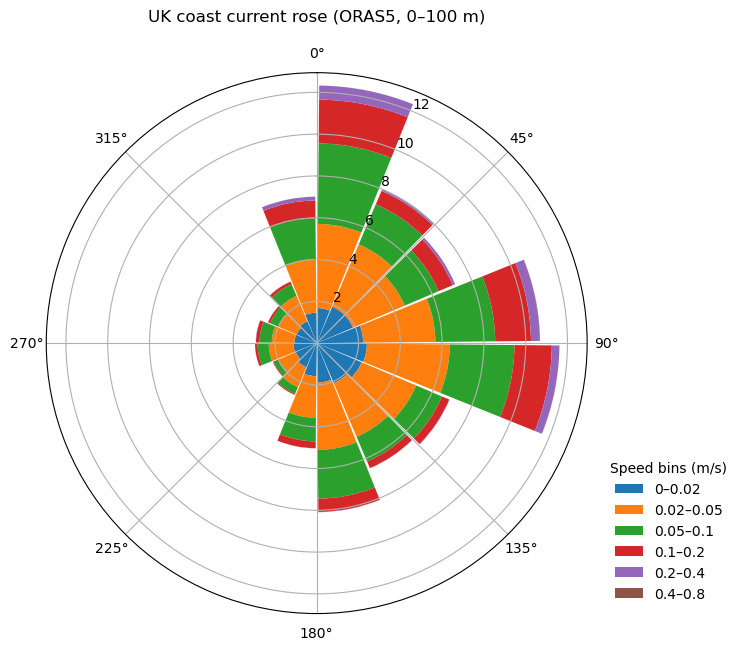

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

def _bearing_to_deg(u, v):
    return (np.degrees(np.arctan2(u, v)) + 360.0) % 360.0

def current_rose_oras5_staggered(
    data_dir,
    region,
    u_var="vozocrtx",
    v_var="vomecrty",
    depth_mode="0_100m",   # "surface", "0_100m", or None
    n_sectors=16,
    speed_bins=(0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8),
    direction="to",
    max_files=60,
    title="Current rose (ORAS5)"
):
    u_files = sorted(Path(data_dir).glob(f"ORAS5_????_??_{VARIABLE_TOKENS['u']}_boxed.nc"))
    v_files = sorted(Path(data_dir).glob(f"ORAS5_????_??_{VARIABLE_TOKENS['v']}_boxed.nc"))

    def ym(p): return (p.name.split("_")[1], p.name.split("_")[2])
    u_map = {ym(p): p for p in u_files}
    v_map = {ym(p): p for p in v_files}
    keys = sorted(set(u_map) & set(v_map))
    if max_files is not None:
        keys = keys[:max_files]

    U_all, V_all = [], []

    def apply_depth(da, depth_name):
        if depth_mode is None:
            return da
        if depth_mode == "surface":
            return da.isel({depth_name: 0}) if depth_name in da.dims else da
        if depth_mode == "0_100m":
            return da.sel({depth_name: slice(0, 100)}).mean(depth_name, skipna=True) if depth_name in da.coords else da
        raise ValueError("depth_mode must be 'surface', '0_100m', or None")

    for k in keys:
        dsu = xr.open_dataset(u_map[k])
        dsv = xr.open_dataset(v_map[k])

        u = dsu[u_var]
        v = dsv[v_var]

        # depth
        if "depthu" in dsu.coords or "depthu" in u.dims:
            u = apply_depth(u, "depthu")
        if "depthv" in dsv.coords or "depthv" in v.dims:
            v = apply_depth(v, "depthv")
        elif "depthu" in dsv.coords or "depthu" in v.dims:
            v = apply_depth(v, "depthu")

        lat_u = dsu["nav_lat"]
        lon_u = wrap_lon(dsu["nav_lon"])
        mask_u = (
            (lat_u >= region["lat_min"]) & (lat_u <= region["lat_max"]) &
            (lon_u >= region["lon_min"]) & (lon_u <= region["lon_max"])
        )

        lat_v = dsv["nav_lat"]
        lon_v = wrap_lon(dsv["nav_lon"])
        mask_v = (
            (lat_v >= region["lat_min"]) & (lat_v <= region["lat_max"]) &
            (lon_v >= region["lon_min"]) & (lon_v <= region["lon_max"])
        )

        u_vals = np.asarray(u.where(mask_u)).ravel()
        v_vals = np.asarray(v.where(mask_v)).ravel()

        u_vals = u_vals[np.isfinite(u_vals)]
        v_vals = v_vals[np.isfinite(v_vals)]

        if u_vals.size == 0 or v_vals.size == 0:
            dsu.close(); dsv.close()
            continue

        n = min(u_vals.size, v_vals.size)
        if u_vals.size > n:
            u_vals = np.random.default_rng(0).choice(u_vals, size=n, replace=False)
        if v_vals.size > n:
            v_vals = np.random.default_rng(1).choice(v_vals, size=n, replace=False)

        U_all.append(u_vals)
        V_all.append(v_vals)

        dsu.close(); dsv.close()

    if not U_all:
        raise ValueError("No valid samples found after subsetting.")

    U = np.concatenate(U_all)
    V = np.concatenate(V_all)

    speed = np.sqrt(U**2 + V**2)
    bearing_to = _bearing_to_deg(U, V)
    bearing = (bearing_to + 180.0) % 360.0 if direction == "from" else bearing_to

    speed_bins = np.asarray(speed_bins)
    sector_edges = np.linspace(0, 360, n_sectors + 1)
    sector_centers = np.deg2rad((sector_edges[:-1] + sector_edges[1:]) / 2)
    sector_width = np.deg2rad(360 / n_sectors)

    counts = np.zeros((n_sectors, len(speed_bins) - 1), dtype=float)
    sec_idx = np.clip(np.digitize(bearing, sector_edges) - 1, 0, n_sectors - 1)
    sp_idx = np.digitize(speed, speed_bins) - 1
    valid = (sp_idx >= 0) & (sp_idx < len(speed_bins) - 1)

    for s, b in zip(sec_idx[valid], sp_idx[valid]):
        counts[s, b] += 1

    counts = 100.0 * counts / counts.sum()

    fig = plt.figure(figsize=(7.5, 7.5))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    bottom = np.zeros(n_sectors)
    for j in range(counts.shape[1]):
        ax.bar(sector_centers, counts[:, j], width=sector_width*0.95, bottom=bottom,
               align="center", edgecolor="none")
        bottom += counts[:, j]

    labels = [f"{speed_bins[i]:.3g}–{speed_bins[i+1]:.3g}" for i in range(len(speed_bins)-1)]
    ax.legend(labels, title="Speed bins (m/s)", loc="lower left",
              bbox_to_anchor=(1.02, 0.0), frameon=False)

    ax.set_title(title, pad=18)
    plt.tight_layout()
    plt.show()


current_rose_oras5_staggered(
    DATA_DIR,
    region=REGIONS["UK_coast"],
    u_var="vozocrtx",
    v_var="vomecrty",
    depth_mode="0_100m",
    max_files=60,
    title="UK coast current rose (ORAS5, 0–100 m)"
)
